# Three Body Capture of PBHs

This tutorial introduces the pipeline used for three body capture simualtions.  


In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt
from astropy import constants as const
from astropy import units as u
from src.ThreeBodyCapture.Simulations.rebound import OrbitalSimulation
from numpy.random import SeedSequence, Generator, PCG64
import src.Utils.calculations as calc
import multiprocessing
import datetime
import src.ThreeBodyCapture.Simulations.population as pop
import src.ThreeBodyCapture.Simulations.threebodycapture as tbc
import src.ThreeBodyCapture.Simulations.threebodyevolution as tbe
import src.Utils.misc as misc
import src.ThreeBodyCapture.Plotting as pl
import os
import pandas as pd
import seaborn as sns
from astropy.cosmology import FlatLambdaCDM
# cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
# H = cosmo.H(0).to(u.yr**-1).value  # Hubble constant in 1/yr
# print(f"Hubble time: {1/H:.2e} yr")
# Simulation Runs



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### PBH Population Generation
Here, we generate the PBH population we will run simulations on. For statistical accuracy, about 1000 PBHs are preferred per node on the mass grid constructed between given min and max mPBH values for a given number n. However, in this tutorial we will have n=10 for convenience.

In [3]:
pbh_pop = pop.PBHPopulation(
    system_name="Sun_Jupiter", 
    mPBH_min=1e-8 * const.M_sun.value,
    mPBH_max=1e-4 * const.M_sun.value,
    mPBH_num=5,
    n_per_mPBH=10,
    seed_start = 0,
    identifier = "tutorial",
    limit_max_v=True
)

Updated system parameter 'mC' to 1.988409870698057e+22 and recalculated rC.
Updated v_inf_grid_params 'max_v' to 30373.502689578207 and regenerated v_inf_grid.
System Parameters:
  mA: 1.988409870698051e+30
  mB: 1.8981245973360505e+27
  mC: 1.988409870698057e+22
  aB: 777908927640.0
  rB: 71492000.0
  rA: 696265000.0
  vB: 13060.0
  eB: 0.0489
  iB: 0.02275909344600606
  epsilon: 0.1
  epsilon_adjust_coeff: 0.1
  name: Sun_Jupiter_s0_Mpbh1e-08_tutorial
  seed_base: 0
  rC: 2.9532500761002588e-05

Simulation Parameters:
  trials: 10000000
  max_trials: 10000000000
  max_execution_time: 3600
  sample_size: 10
  max_e: 1.0
  vDM: 220000.0
  v_inf_grid_params: {'min_v': 1000, 'max_v': np.float64(30373.502689578207), 'n_v': 10}
  importance_sampling: True
  v_inf_grid: [ 1000.          4263.72252106  7527.44504213 10791.16756319
 14054.89008426 17318.61260532 20582.33512639 23846.05764745
 27109.78016851 30373.50268958]
Prepared configuration for mPBH = 1.0000000000000032e-08 solar masses.

## Three Body Capture Simulation
Here we initialize and run the capture simulation for the population generated above.

In [39]:
tbodycap = tbc.ThreeBodyCapture(pbh_pop.population_dict)
tbodycap.run_simulation(num_cores=4)


Running 50 Monte Carlo simulations
Using 4 cores



Progress: 50/50 (100.0%), elapsed 0:00:01, estimated remaining time: 0:00:00

✓ ALL MONTE CARLO SIMULATIONS COMPLETE!
Total time: 0.02 min
Average: 0.02 sec/simulation



### Post MC sampling
Before proceeding with the evolution simulation, a sample dictionary needs to be created by capture simulation results.

In [4]:
print(pbh_pop.sample_mc())

Analyzing Monte Carlo results for configuration: Sun_Jupiter_s0_Mpbh1e-08_tutorial
Loading MC results from: /data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_s0_Mpbh1e-08_tutorial/Monte_Carlo_Results/
Loading Rebound results from: /data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_s0_Mpbh1e-08_tutorial/Rebound_Simulation_Results/
Rebound results loading is disabled. Only MC results will be processed. Results dictionary not generated.
Analyzing Monte Carlo results for configuration: Sun_Jupiter_s1_Mpbh1e-07_tutorial
Loading MC results from: /data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_s1_Mpbh1e-07_tutorial/Monte_Carlo_Results/
Loading Rebound results from: /data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_s1_Mpbh1e-07_tutorial/Rebound_Simulation_Results/
Rebound results loading is disabled. Only MC results will be processed. Results dictionary not generated.
Analyzing Monte Carlo results for configuration: Sun_Jupiter_s2_Mpbh1e-06_tutorial
Loading MC results from: /data/a.saricaoglu/repo/ca

## Three Body Evolution Simulation
Now we initialize and run the evolution simulation for the captured PBH population using sampled results above.

In [37]:
tbodyev = tbe.ThreeBodyEvolution(pbh_pop.population_dict, verbose=False)
tbodyev.run_simulation(num_cores=10)

Preparing Sun_Jupiter_s0_Mpbh1e-08_tutorial...
  Added 30 simulations (skipped 70)
Preparing Sun_Jupiter_s1_Mpbh1e-07_tutorial...
  Added 100 simulations (skipped 0)
Preparing Sun_Jupiter_s2_Mpbh1e-06_tutorial...
  Added 100 simulations (skipped 0)
Preparing Sun_Jupiter_s3_Mpbh1e-05_tutorial...
  Added 100 simulations (skipped 0)
Preparing Sun_Jupiter_s4_Mpbh1e-04_tutorial...
  Added 100 simulations (skipped 0)

Running 430 total simulations across 5 runs
Using 10 cores



Progress: 430/430 (100.0%), elapsed 1:06:43, estimated remaining time 0:00:00

✓ ALL RUNS COMPLETE!
Total time: 1:06:43.518884 (66.73 min)
Average: 9.31 sec/simulation


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

## Analysing Results

In [5]:
pbh_pop.analyze_population()

Analyzing final results for configuration: Sun_Jupiter_s0_Mpbh1e-08_tutorial
Loading MC results from: /data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_s0_Mpbh1e-08_tutorial/Monte_Carlo_Results/
Loading Rebound results from: /data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_s0_Mpbh1e-08_tutorial/Rebound_Simulation_Results/
Using cached results dictionary.
Analyzing final results for configuration: Sun_Jupiter_s1_Mpbh1e-07_tutorial
Loading MC results from: /data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_s1_Mpbh1e-07_tutorial/Monte_Carlo_Results/
Loading Rebound results from: /data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_s1_Mpbh1e-07_tutorial/Rebound_Simulation_Results/
Using cached results dictionary.
Analyzing final results for configuration: Sun_Jupiter_s2_Mpbh1e-06_tutorial
Loading MC results from: /data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_s2_Mpbh1e-06_tutorial/Monte_Carlo_Results/
Loading Rebound results from: /data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_s2_Mpbh1e-06_tutorial

Make a list of analyses to create a table for the capture rates, number of system in equilibrium, number of system in equilibrium for total PBH fraction, and number of system in equilibrium for the PBH fraction bounded by observations; at r-8 kpc (Solar vicinity) from the galactic center.

In [7]:
pop_dict = pbh_pop.get_population_dict()

analysis_list = []
for pop in list(pop_dict.values()):
    analysis_list.append(pop["analysis"])
    

In [8]:
Rjup_au = (const.R_jup).to(u.au)
Ajupiter = np.pi * (Rjup_au.value)**2
table = misc.create_analysis_pandas_table(
    analysis_list=analysis_list,
    err_list=['total_cap_err', 'total_neq_err', 'full_neq_err', 'bound_neq_err'],
    # qval_list=['total_cap_qvals', 'total_neq_qvals', None],
    # err_list=['total_cap_err', 'total_neq_err', None],
    rows=[['total_occurrences_gl', 'capture_rate_gl'], ['total_occurrences_gl', 'total_systems_neq_gl'],['total_pbh_neq_n', 'Neq_pbh_f_full'], ['total_pbh_neq_n', 'Neq_pbh_f_bound']],
    row_labels=[r'R$_{cap, k}$ [Myr$^{-1}$]', r'N$_{eq, k}$ [n$_\infty$ AU$^{3}$]', r'N$_{\mathrm{eq}, k}(f_{total})$', r'N$_{\mathrm{eq}, k}(f_{bound})$'],
    unit_change=[1e6, 1, 1, 1],
    symmetric_errors=True,
    decimal_places=[1,2],
    ci_unit_change=[1e6, 1, 1, 1],
    err_sigma=2,
    sc_notation=[False, False, True, True],

)
row_labels=[r'R$_{cap, k}$ [Myr$^{-1}$]', r'N$_{eq, k}$ [n$_\infty$ AU$^{3}$]', r'N$_{\mathrm{eq}, k}(f_{total})$', r'N$_{\mathrm{eq}, k}(f_{bound})$']
table
# print(table.to_latex('capture_rates_table_SJ_Set12combined_r0.05kpc.tex', index=row_labels))

Rows data for table: [['0.3 $\\pm$ 0.1', '0.3 $\\pm$ 0.2', '0.4 $\\pm$ 0.2', '0.26 $\\pm$ 0.09', '0.3 $\\pm$ 0.1'], ['0.15 $\\pm$ 0.06', '0.10 $\\pm$ 0.04', '0.18 $\\pm$ 0.07', '0.20 $\\pm$ 0.07', '0.12 $\\pm$ 0.05'], ['$(2.1 \\pm 0.8) \\times 10^{-11}$', '$(1.4 \\pm 0.5) \\times 10^{-12}$', '$(2.5 \\pm 1.0) \\times 10^{-13}$', '$(2.8 \\pm 1.0) \\times 10^{-14}$', '$(1.7 \\pm 0.8) \\times 10^{-15}$'], ['$(2.1 \\pm 0.8) \\times 10^{-13}$', '$(3 \\pm 1) \\times 10^{-15}$', '$(3 \\pm 1) \\times 10^{-16}$', '$(4 \\pm 1) \\times 10^{-17}$', '$(3 \\pm 1) \\times 10^{-18}$']]
Column labels for table: ['1.0000000000000032e-08', '1.0000000000000031e-07', '1.0000000000000031e-06', '1.0000000000000031e-05', '0.0001000000000000003']


,1.0000000000000032e-08,1.0000000000000031e-07,1.0000000000000031e-06,1.0000000000000031e-05,0.0001000000000000003
"R$_{cap, k}$ [Myr$^{-1}$]",0.3 $\pm$ 0.1,0.3 $\pm$ 0.2,0.4 $\pm$ 0.2,0.26 $\pm$ 0.09,0.3 $\pm$ 0.1
"N$_{eq, k}$ [n$_\infty$ AU$^{3}$]",0.15 $\pm$ 0.06,0.10 $\pm$ 0.04,0.18 $\pm$ 0.07,0.20 $\pm$ 0.07,0.12 $\pm$ 0.05
"N$_{\mathrm{eq}, k}(f_{total})$",$(2.1 \pm 0.8) \times 10^{-11}$,$(1.4 \pm 0.5) \times 10^{-12}$,$(2.5 \pm 1.0) \times 10^{-13}$,$(2.8 \pm 1.0) \times 10^{-14}$,$(1.7 \pm 0.8) \times 10^{-15}$
"N$_{\mathrm{eq}, k}(f_{bound})$",$(2.1 \pm 0.8) \times 10^{-13}$,$(3 \pm 1) \times 10^{-15}$,$(3 \pm 1) \times 10^{-16}$,$(4 \pm 1) \times 10^{-17}$,$(3 \pm 1) \times 10^{-18}$


By default, analysis calculations take r = 8 kpc. However, analysis can be done for any r, To do that, we provide r value and set update=True when calling get_combined_dictionary() or using update_results_dictionary(r).

In [9]:
analysis_list = []
for pop in list(pop_dict.values()):
    a = pop["analysis"]
    a.update_results_dictionary(r=0.05)
    analysis_list.append(a)
    
table = misc.create_analysis_pandas_table(
    analysis_list=analysis_list,
    err_list=['total_cap_err', 'total_neq_err', 'full_neq_err', 'bound_neq_err'],
    # qval_list=['total_cap_qvals', 'total_neq_qvals', None],
    # err_list=['total_cap_err', 'total_neq_err', None],
    rows=[['total_occurrences_gl', 'capture_rate_gl'], ['total_occurrences_gl', 'total_systems_neq_gl'],['total_pbh_neq_n', 'Neq_pbh_f_full'], ['total_pbh_neq_n', 'Neq_pbh_f_bound']],
    row_labels=[r'R$_{cap, k}$ [Myr$^{-1}$]', r'N$_{eq, k}$ [n$_\infty$ AU$^{3}$]', r'N$_{\mathrm{eq}, k}(f_{total})$', r'N$_{\mathrm{eq}, k}(f_{bound})$'],
    unit_change=[1e6, 1, 1, 1],
    symmetric_errors=True,
    decimal_places=[1,2],
    ci_unit_change=[1e6, 1, 1, 1],
    err_sigma=2,
    sc_notation=[False, False, True, True],

)
row_labels=[r'R$_{cap, k}$ [Myr$^{-1}$]', r'N$_{eq, k}$ [n$_\infty$ AU$^{3}$]', r'N$_{\mathrm{eq}, k}(f_{total})$', r'N$_{\mathrm{eq}, k}(f_{bound})$']
table

Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Using cached data in results dictionary as base for update, (MC and Rebound data not relaoded).
Rows data for table: [['8 $\\pm$ 3', '9 $\\pm$ 5', '10 $\\pm$ 6', '7 $\\pm$ 2', '8 $\\pm$ 4'], ['4 $\\pm$ 1', '2.7 $\\pm$ 1.0', '5 $\\pm$ 2', '5 $\\pm$ 2', '3 $\\pm$ 1'], ['$(4 \\pm 1) \\times 10^{-9}$', '$(2.6 \\pm 1.0) \\times 10^{-10}$', '$(5 \\pm 2) \\times 10^{-11}$', '$(5 \\pm 2) \\times 10^{-12}$', '$(3 \\pm 1) \\times 10^{-13}$'], ['$(4 \\pm 1) \\times 10^{-11}$', '$(5 \\pm 2) \\times 10^{-13}$', '$(6 \\pm 2) \\times 10^{-14}$', '$(7 \\pm 2) \\times 10^{-15}$', '$(6 \\pm 3) \\times 10^{-16}$']]
Column label

,1.0000000000000032e-08,1.0000000000000031e-07,1.0000000000000031e-06,1.0000000000000031e-05,0.0001000000000000003
"R$_{cap, k}$ [Myr$^{-1}$]",8 $\pm$ 3,9 $\pm$ 5,10 $\pm$ 6,7 $\pm$ 2,8 $\pm$ 4
"N$_{eq, k}$ [n$_\infty$ AU$^{3}$]",4 $\pm$ 1,2.7 $\pm$ 1.0,5 $\pm$ 2,5 $\pm$ 2,3 $\pm$ 1
"N$_{\mathrm{eq}, k}(f_{total})$",$(4 \pm 1) \times 10^{-9}$,$(2.6 \pm 1.0) \times 10^{-10}$,$(5 \pm 2) \times 10^{-11}$,$(5 \pm 2) \times 10^{-12}$,$(3 \pm 1) \times 10^{-13}$
"N$_{\mathrm{eq}, k}(f_{bound})$",$(4 \pm 1) \times 10^{-11}$,$(5 \pm 2) \times 10^{-13}$,$(6 \pm 2) \times 10^{-14}$,$(7 \pm 2) \times 10^{-15}$,$(6 \pm 3) \times 10^{-16}$


## Visualization

An example of how orbital configuration for a choosen mPBH and vPBH.

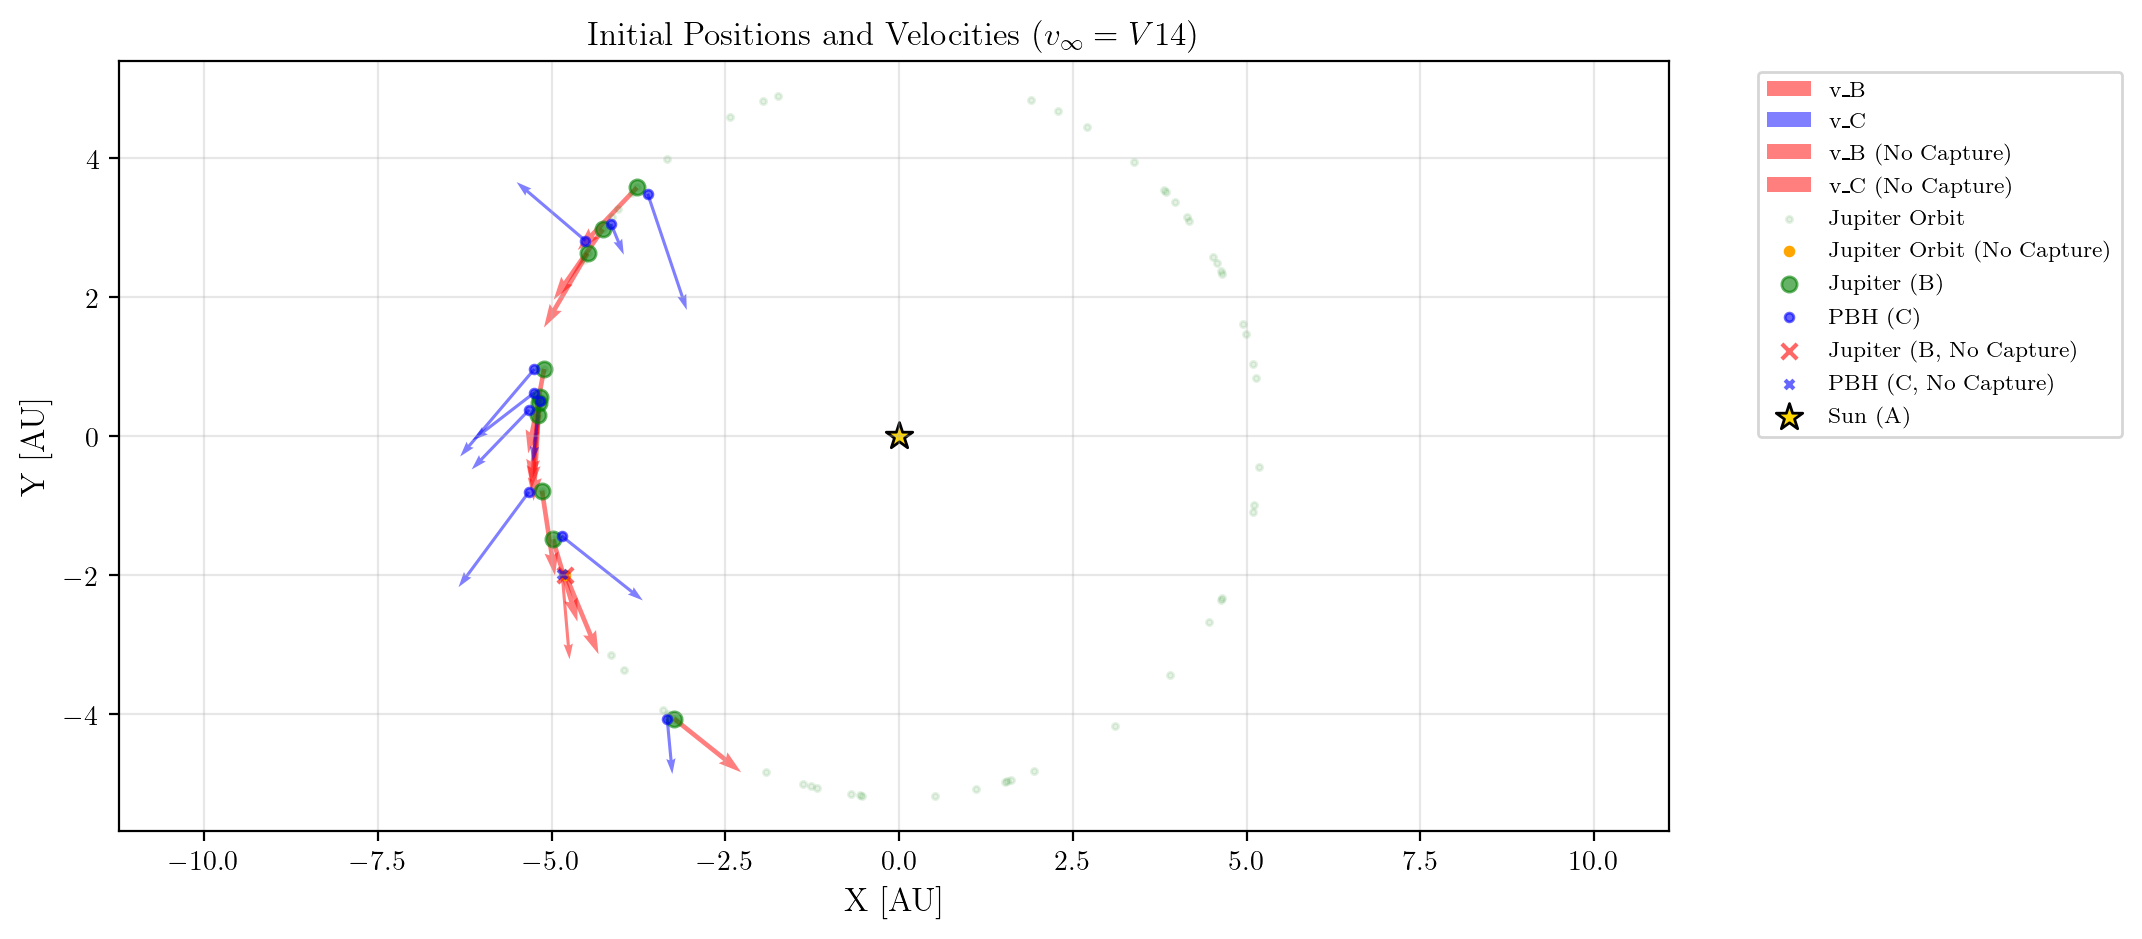

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
# Get data from sampled_mc

plt.close('all')
n = 'Sun_Jupiter_s0_Mpbh1e-08_tutorial'
sampled_mc = pop_dict[n]['sampled_mc']
catalog = pop_dict[n]['analysis_results']

m = list(sampled_mc.keys())[4]  # First velocity key
# Extract positions and velocities (in AU and AU/yr)
pos_C = (np.array(sampled_mc[m]['cap_C_pos']) * u.m).to(u.au).value
pos_B = (np.array(sampled_mc[m]['cap_B_pos']) * u.m).to(u.au).value
v_C = (np.array(sampled_mc[m]['cap_C_v2']) * u.m/u.s).to(u.au/u.yr).value
v_B = (np.array(sampled_mc[m]['cap_B_v']) * u.m/u.s).to(u.au/u.yr).value
nocap_pos_C = (np.array(sampled_mc[m]['nocap_C_pos']) * u.m).to(u.au).value
nocap_pos_B = (np.array(sampled_mc[m]['nocap_B_pos']) * u.m).to(u.au).value
nocap_v_C = (np.array(sampled_mc[m]['nocap_C_v2']) * u.m/u.s).to(u.au/u.yr).value
nocap_v_B = (np.array(sampled_mc[m]['nocap_B_v']) * u.m/u.s).to(u.au/u.yr).value
v_inf = (np.array(sampled_mc[m]['v_inf']) * u.m/u.s).to(u.km/u.s).value
lambda_all = (np.array(sampled_mc[m]['all_lambda']))
lambda_nocap = (np.array(sampled_mc[m]['nocap_lambda']))
aB = (np.array(catalog['aB']))
velocities_in_B_frame = v_C - v_B  # Relative velocity of PBH in Jupiter's frame
# # # 2D plot (XY plane)
rABVec = np.array([calc.r_AB_vec(aB, lambda_all[i]) for i in range(len(lambda_all))])* u.m.to(u.au)
fig, ax = plt.subplots(figsize=(10, 5))
rABVec_nocap = np.array([calc.r_AB_vec(aB, lambda_nocap[i]) for i in range(len(lambda_nocap))])* u.m.to(u.au)

# Plot positions


# Plot velocity vectors (scaled for visibility)
scale = 0.05  # Adjust this to make arrows visible
ax.quiver(pos_B[:, 0], pos_B[:, 1], v_B[:, 0]*scale, v_B[:, 1]*scale, 
          color='red', alpha=0.5, width=0.003, label='v_B' )
ax.quiver(pos_C[:, 0], pos_C[:, 1], v_C[:, 0]*scale, v_C[:, 1]*scale, 
          color='blue', alpha=0.5, width=0.002, label='v_C')
ax.quiver(nocap_pos_B[:, 0], nocap_pos_B[:, 1], nocap_v_B[:, 0]*scale, nocap_v_B[:, 1]*scale, 
          color='red', alpha=0.5, width=0.003, label='v_B (No Capture)')
ax.quiver(nocap_pos_C[:, 0], nocap_pos_C[:, 1], nocap_v_C[:, 0]*scale, nocap_v_C[:, 1]*scale, 
          color='red', alpha=0.5, width=0.002, label='v_C (No Capture)')
ax.scatter(rABVec[:, 0], rABVec[:, 1], c='green', label='Jupiter Orbit', s=5, alpha=0.1)
ax.scatter(rABVec_nocap[:, 0], rABVec_nocap[:, 1], c='orange', label='Jupiter Orbit (No Capture)', s=10, alpha=1)
ax.scatter(pos_B[:, 0], pos_B[:, 1], c='green', label='Jupiter (B)', s=30, alpha=0.6)
ax.scatter(pos_C[:, 0], pos_C[:, 1], c='blue', label='PBH (C)', s=10, alpha=0.6)
ax.scatter(nocap_pos_B[:, 0], nocap_pos_B[:, 1], c='red', label='Jupiter (B, No Capture)', s=30, alpha=0.6, marker='x')
ax.scatter(nocap_pos_C[:, 0], nocap_pos_C[:, 1], c='blue', label='PBH (C, No Capture)', s=10, alpha=0.6, marker='x')
ax.scatter(0, 0, c='gold', s=100, marker='*', label='Sun (A)', edgecolors='black')
ax.set_xlabel('X [AU]')
ax.set_ylabel('Y [AU]')
ax.set_title(rf'Initial Positions and Velocities ($v_\infty = {m}$)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
ax.axis('equal')
plt.show()


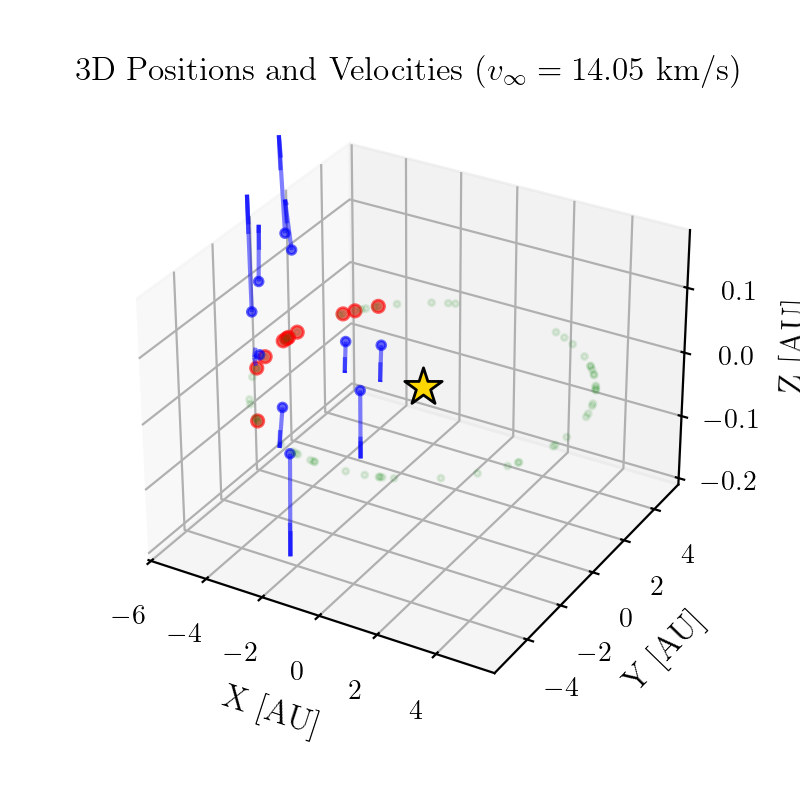

In [12]:
%matplotlib widget
# 3D plot
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(pos_B[:, 0], pos_B[:, 1], pos_B[:, 2], c='red', label='Jupiter (B)', s=20, alpha=0.6)
ax.scatter(pos_C[:, 0], pos_C[:, 1], pos_C[:, 2], c='blue', label='PBH (C)', s=10, alpha=0.6)
ax.scatter(0, 0, 0, c='gold', s=200, marker='*', label='Sun (A)', edgecolors='black')
ax.scatter(rABVec[:, 0], rABVec[:, 1], c='green', label='Jupiter Orbit', s=5, alpha=0.1)

# 3D velocity vectors
# ax.quiver(pos_B[:, 0], pos_B[:, 1], pos_B[:, 2], 
#           v_B[:, 0]*scale, v_B[:, 1]*scale, v_B[:, 2]*scale,
#           color='red', alpha=0.5, arrow_length_ratio=0.3)
ax.quiver(pos_C[:, 0], pos_C[:, 1], pos_C[:, 2],
          v_C[:, 0]*scale, v_C[:, 1]*scale, v_C[:, 2]*scale,
          color='blue', alpha=0.5, arrow_length_ratio=0.3)

ax.set_xlabel('X [AU]')
ax.set_ylabel('Y [AU]')
ax.set_zlabel('Z [AU]')
ax.set_title(fr'3D Positions and Velocities ($v_\infty = {v_inf:.2f}$ km/s)')
# ax.legend()
plt.show()

### Close Encounter Geometry
Here, we inspect the close encounter configuration in detail. Incoming and outgoing (rotated) vector directions must be consistent with the close encounter calculations.

0.1


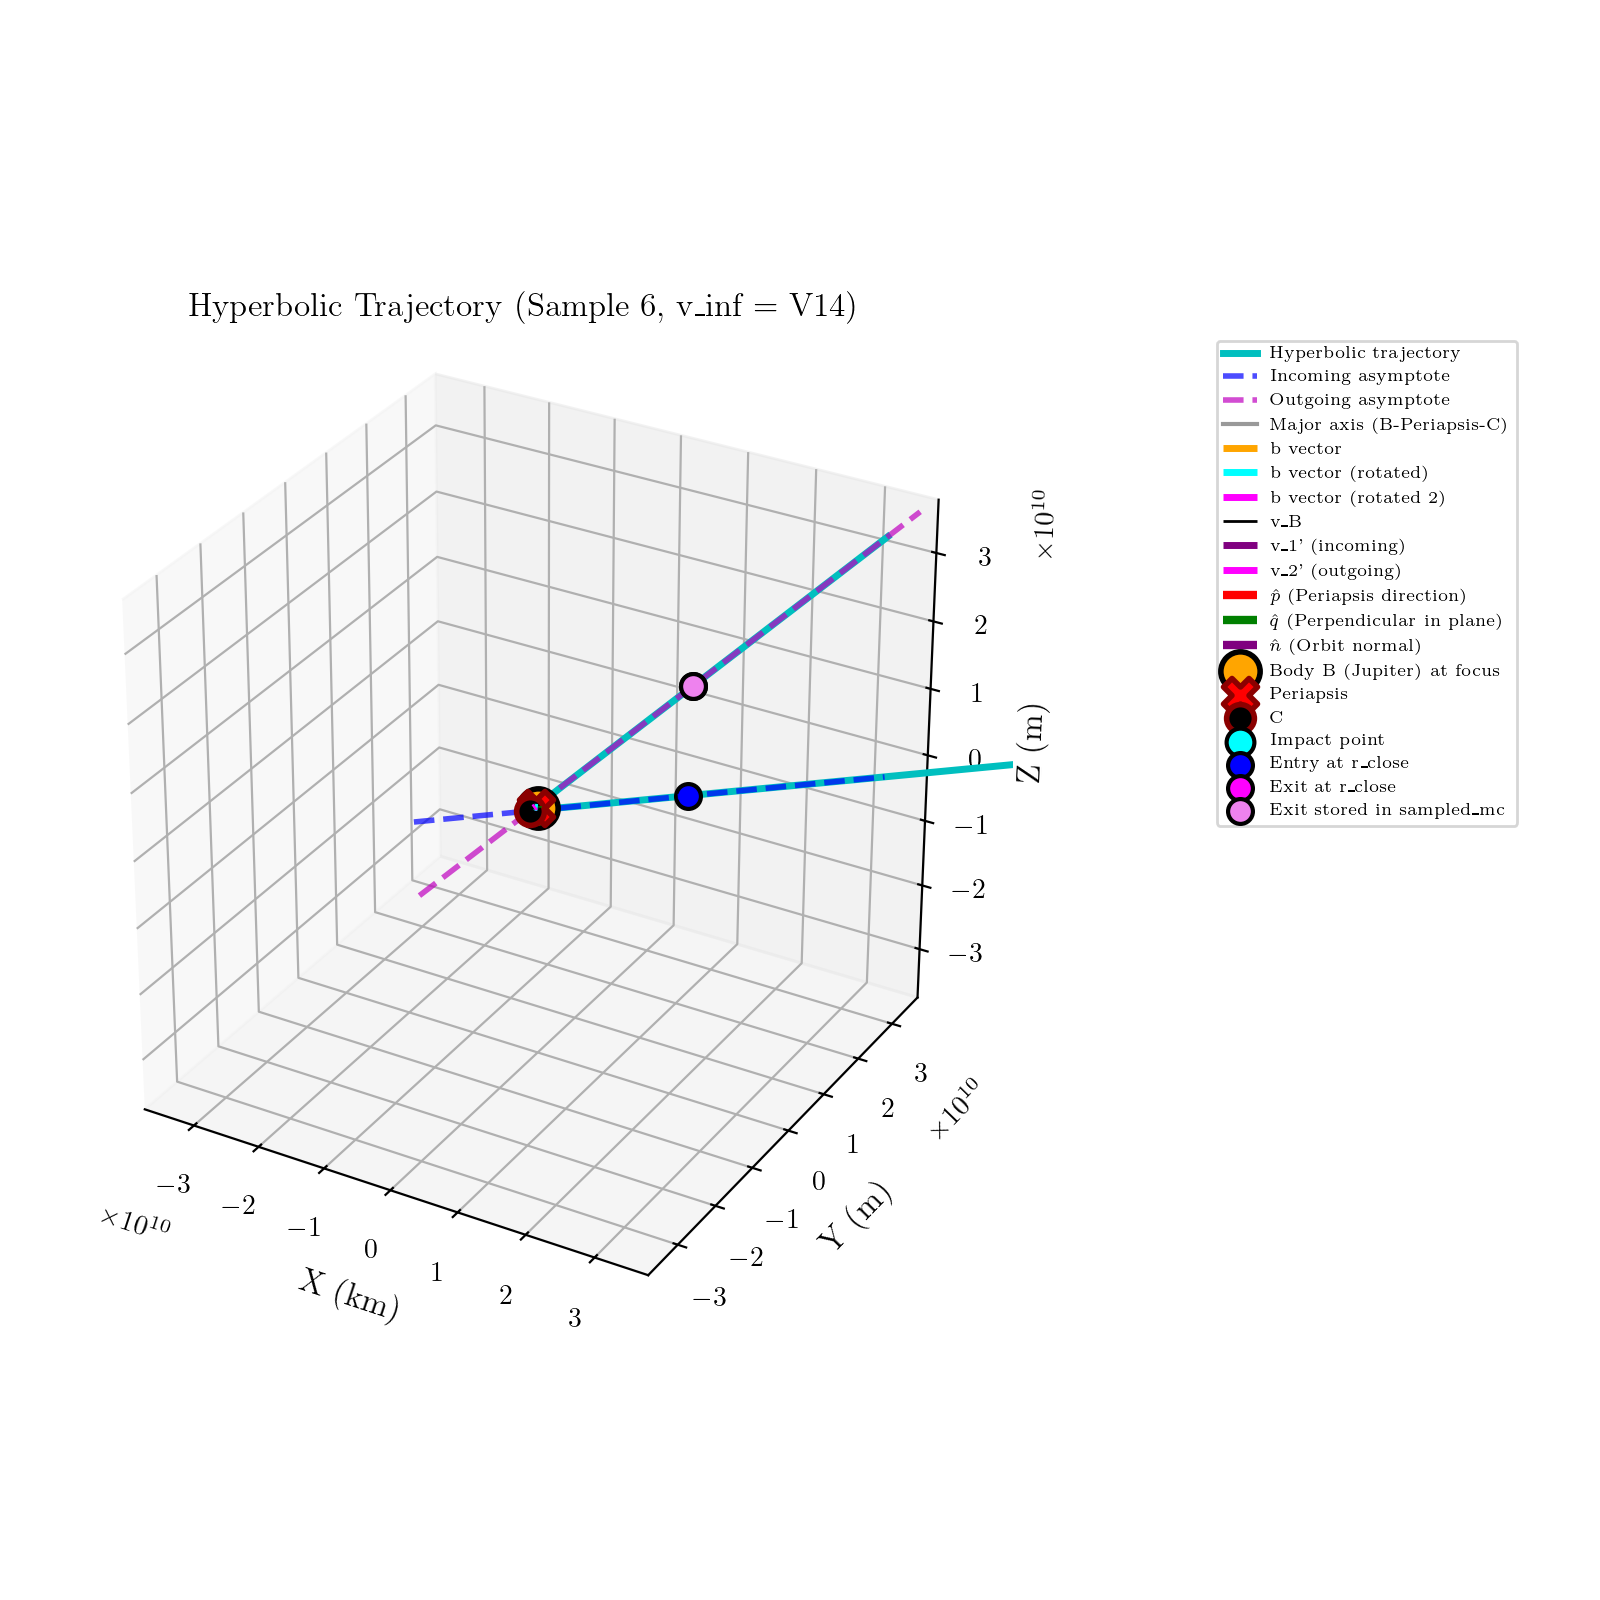

=== Trajectory Verification ===
v_inf key: V14
Sample index: 6
Eccentricity: 1.2657
Periapsis distance: 2.33e+08 m (3.26 R_Jup)
Impact parameter b: 6.80e+08 m
Deflection angle: 284.38°
Exit distance (B frame): 2.82e+10 m (should ≈ 2.82e+10 m)

Exit position (A frame, calculated): [-7.26764902e+11 -2.15023772e+11  1.98692716e+10] m
Exit position (A frame, stored):     [-7.26764902e+11 -2.15023772e+11  1.98692716e+10] m
Difference: 0.00e+00 m
Match: True

=== Coordinate System Check ===
Stored exit (B frame):      [1.88423502e+10 6.81429032e+09 1.98692716e+10]
Calculated exit (B frame):  [1.88423502e+10 6.81429032e+09 1.98692716e+10]
B-frame difference:         1.71e-05 m

=== Checking if positions lie on same hyperbola ===
Stored exit radius: 2.82e+10 m
Calculated exit radius: 2.82e+10 m
θ from stored position: 140.83°
θ calculated: 140.83°

=== v1' Reconstruction ===
v1primeVec (reconstructed): [ -3724.34997335 -10909.54783766   3424.75652083]
v1primeMag (reconstructed): 1.20e+04 m/s



In [13]:
# Visualize initial conditions from actual sampled_mc data
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import src.Utils.calculations as calc
%matplotlib widget
plt.close('all')
# Get data from sampled_mc (already loaded)

# print(f"Visualizing trajectory for v_inf = {v_inf:.2f} m/s")
# configuration = runs_dict[list(runs_dict.keys())[3]]['configuration']
# sampled_mc = runs_dict[list(runs_dict.keys())[3]]['sampled_mc']
# m = list(sampled_mc.keys())[-1]  # First velocity key
configuration = pop_dict[n]['configuration']
v_inf = sampled_mc[m]['v_inf'] 
G = const.G.value
mA = configuration.get_system_param('mA')
mB = configuration.get_system_param('mB')
mC = configuration.get_system_param('mC')
epsilon = configuration.get_system_param('epsilon')  # Softening parameter for r_close calculation
print(epsilon)
vBMag = configuration.get_system_param('vB')  # Jupiter velocity magnitude
muA = calc.standard_gravitational_parameter(mA, mC)
muB = calc.standard_gravitational_parameter(mB, mC)
idx = 6 
# Get the parameters
pos_C_m = sampled_mc[m]['cap_C_pos'][idx]  # Exit position in meters
pos_B_m = sampled_mc[m]['cap_B_pos'][idx]  # Jupiter position
v_C_m_s = sampled_mc[m]['cap_C_v2'][idx]   # v2' in m/s
v_B_m_s = sampled_mc[m]['cap_B_v'][idx]    # vB in m/s
# v1prime_m_s = sampled_mc[m]['cap_C_v1prime'][idx]  # v1' in m/s
b_m = sampled_mc[m]['cap_b'][idx]  # Impact parameter
phi = sampled_mc[m]['cap_phi'][idx]
beta = sampled_mc[m]['cap_beta'][idx]
lambda1 = sampled_mc[m]['cap_lambda'][idx]
aB = configuration.get_system_param('aB')
rClose = calc.r_close(epsilon, muA, muB, aB)
aC = aB - rClose
v1Mag = calc.v_1_mag(v_inf, muA, muB, aC, rClose)
v1Vec = calc.v_1_vec(v1Mag, beta)

# Calculate vB vector
vBVec = calc.v_B_vec(vBMag, lambda1)

# Calculate r_AB vector
rABVec = calc.r_AB_vec(aB, lambda1)

# Calculate v1_prime (velocity in frame of body B)
v1primeVec = calc.v_1_prime_vec(v1Vec, vBVec)
v1primeMag = calc.v_1_prime_mag(v1primeVec)
# Calculate impact parameter b (example value)
b = b_m
b_hat = calc.b_unit_vector(v1primeMag, v1primeVec, phi)
b_vec = b * b_hat

# v2primeVec = calc.v_2_prime_vec(v1primeVec, v1primeMag, muB, b, phi)  # b=0 for head-on

v2Vec = v_C_m_s # Transform to A frame
v2primeVec = v2Vec - vBVec  # Transform to B frame

v2Mag = calc.v_2_mag(v2Vec)


cosPsi = calc.cos_psi(muB, b ,v1primeMag)
psi = calc.deflection_angle(cosPsi)
# Extract ONE example to visualize the hyperbolic trajectory


# Calculate hyperbolic trajectory parameters
a_hyp = -muB / v1primeMag**2  # negative for hyperbola
e = np.sqrt(1.0 + (b_m * v1primeMag**2 / muB)**2)
l = a_hyp * (1 - e**2)  # semi-latus rectum
rp = -a_hyp * (e - 1)   # periapsis distance
theta_inf = np.arccos(-1.0/e)

# Build coordinate system
s_in = calc.unit(v1primeVec)  # Incoming asymptote direction
b_vec = b_m * calc.b_unit_vector(v1primeMag, v1primeVec, phi)
n_hat = calc.unit(np.cross(b_vec, s_in))

# Calculate p_hat and q_hat (periapsis direction)
theta = np.arccos(1.0/e)
p_hat = calc.rodrigues_rotate(s_in, n_hat, -theta)
q_hat = np.cross(n_hat, p_hat)
b_vec_rotated = calc.rodrigues_rotate(b_vec, n_hat, psi)
b_vec_rotated_2 = np.cos(psi) * b_hat + np.sin(psi) * s_in
# Generate hyperbolic trajectory
theta_traj = np.linspace(-theta_inf + 0.001, theta_inf - 0.001, 500)
r_traj = l / (1 + e * np.cos(theta_traj))
x_traj = r_traj * np.cos(theta_traj)
y_traj = r_traj * np.sin(theta_traj)
r_traj_3d = np.array([x_traj * p_hat[i] + y_traj * q_hat[i] for i in range(3)])

# Key positions
periapsis_pos = rp * p_hat
C_pos = (rp + np.abs(a_hyp)) * p_hat
v2prime_direction = calc.unit(v2primeVec)  # Outgoing direction based on actual velocities
theta_entry = np.arccos((l/rClose - 1)/e)
entry_at_rclose = rClose * np.cos(-theta_entry) * p_hat + rClose * np.sin(-theta_entry) * q_hat
exit_at_rclose = rClose * np.cos(theta_entry) * p_hat + rClose * np.sin(theta_entry) * q_hat

# Asymptote directions
asymp_in_dir = -(np.cos(-theta_inf) * p_hat + np.sin(-theta_inf) * q_hat)
asymp_out_dir = np.cos(theta_inf) * p_hat + np.sin(theta_inf) * q_hat

asymp_length = 100 * b_m


incoming_start = C_pos + asymp_length * asymp_in_dir * 0.3
incoming_end = C_pos - asymp_length * asymp_in_dir

# Outgoing asymptote: passes through C in outgoing direction
outgoing_start = C_pos - asymp_length * asymp_out_dir * 0.3
outgoing_end = C_pos + asymp_length * asymp_out_dir
origin = np.array([0,0,0])
# Visualize
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot hyperbolic trajectory (Body B at origin in its frame)
ax.plot(r_traj_3d[0], r_traj_3d[1], r_traj_3d[2],
        'c-', linewidth=2.5, label='Hyperbolic trajectory', zorder=2)

# Plot incoming asymptote
ax.plot([incoming_start[0], incoming_end[0]], 
        [incoming_start[1], incoming_end[1]], 
        [incoming_start[2], incoming_end[2]],
        'b--', linewidth=2, alpha=0.7, label='Incoming asymptote', zorder=3)

# Plot outgoing asymptote
ax.plot([outgoing_start[0], outgoing_end[0]], 
        [outgoing_start[1], outgoing_end[1]], 
        [outgoing_start[2], outgoing_end[2]],
        'm--', linewidth=2, alpha=0.7, label='Outgoing asymptote', zorder=3)

# Plot line connecting B (origin), periapsis, and C (center) along major axis
ax.plot([0, periapsis_pos[0], C_pos[0]], 
        [0, periapsis_pos[1], C_pos[1]], 
        [0, periapsis_pos[2], C_pos[2]],
        'k-', linewidth=1.5, alpha=0.4, label='Major axis (B-Periapsis-C)', zorder=1)

# b vector from Body B (origin)
ax.quiver(0, 0, 0, b_vec[0], b_vec[1], b_vec[2],
          color='orange', arrow_length_ratio=0.08, linewidth=2.5, label='b vector')
# b vector rotated to show direction towards periapsis
ax.quiver(0, 0, 0, b_vec_rotated[0], b_vec_rotated[1], b_vec_rotated[2],
          color='cyan', arrow_length_ratio=0.08, linewidth=2.5, label='b vector (rotated)')
# b vector rotated to show direction towards periapsis

ax.quiver(0, 0, 0, b_vec_rotated_2[0], b_vec_rotated_2[1], b_vec_rotated_2[2],
          color='magenta', arrow_length_ratio=0.08, linewidth=2.5, label='b vector (rotated 2)')
# vB vector from Body B (origin)
vBVec_norm = v_B_m_s / np.linalg.norm(v_B_m_s) * b_m * 0.6   # Scale for visibility
ax.quiver(0, 0, 0, vBVec_norm[0], vBVec_norm[1], vBVec_norm[2], 
          color='black', arrow_length_ratio=0.08, linewidth=1, label='v_B')
# v1' along incoming asymptote
v1prime_scale = b_m * 0.5  # Scale for visibility
v1prime_pos = b_vec - b_m * s_in  # Position along incoming asymptote
ax.quiver(v1prime_pos[0], v1prime_pos[1], v1prime_pos[2],
          v1prime_scale * s_in[0], v1prime_scale * s_in[1], v1prime_scale * s_in[2], 
          color='purple', arrow_length_ratio=0.1, linewidth=2.5, label='v_1\' (incoming)')

# v2' along outgoing asymptote  
v2prime_pos = C_pos + b_m * v2prime_direction
ax.quiver(v2prime_pos[0], v2prime_pos[1], v2prime_pos[2],
          v1prime_scale * v2prime_direction[0], v1prime_scale * v2prime_direction[1], v1prime_scale * v2prime_direction[2], 
          color='magenta', arrow_length_ratio=0.1, linewidth=2.5, label='v_2\' (outgoing)')
# p_hat 
# Plot the orthonormal basis vectors (p_hat, q_hat, n_hat)
ax.quiver(*origin, *p_hat *v1prime_scale , color='red', arrow_length_ratio=0.4, linewidth=3, 
          label=r'$\hat{p}$ (Periapsis direction)')
ax.quiver(*origin, *q_hat*v1prime_scale, color='green', arrow_length_ratio=0.4, linewidth=3, 
          label=r'$\hat{q}$ (Perpendicular in plane)')
ax.quiver(*origin, *n_hat*v1prime_scale, color='purple', arrow_length_ratio=0.4, linewidth=3, 
          label=r'$\hat{n}$ (Orbit normal)')
# Mark key points
ax.scatter([0], [0], [0], color='orange', s=200, label='Body B (Jupiter) at focus', 
           edgecolors='black', linewidths=2, zorder=5, marker='o')

# Periapsis
# periapsis_pos = rp * p_hat
 
ax.scatter([periapsis_pos[0]], [periapsis_pos[1]], [periapsis_pos[2]], 
           color='red', s=150, marker='X', label='Periapsis', 
           edgecolors='darkred', linewidths=2, zorder=6)
ax.scatter([C_pos[0]], [C_pos[1]], [C_pos[2]], 
           color='black', s=100, marker='o', label='C', 
           edgecolors='darkred', linewidths=2, zorder=6)
# Impact point (tip of b vector)
ax.scatter([b_vec[0]], [b_vec[1]], [b_vec[2]], 
           color='cyan', s=100, marker='o', label='Impact point', 
           edgecolors='black', linewidths=1.5, zorder=5)
# Entry and exit points at r_close
# entry_pos = l / (1 + e * np.cos(-theta_inf + 0.05)) * (-np.cos(-theta_inf + 0.05) * p_hat + np  .sin(-theta_inf + 0.05) * q_hat)
# exit_pos = l / (1 + e * np.cos(theta_inf - 0.05)) * (-np.cos(theta_inf - 0.05) * p_hat + np.sin(theta_inf - 0.05) * q_hat)
pos_C_B_frame = pos_C_m - pos_B_m  # Transform C's position to B's frame
ax.scatter([entry_at_rclose[0]], [entry_at_rclose[1]], [entry_at_rclose[2]], 
           color='blue', s=80, marker='o', label='Entry at r_close', 
           edgecolors='black', linewidths=1.5, zorder=5)
ax.scatter([exit_at_rclose[0]], [exit_at_rclose[1]], [exit_at_rclose[2]], 
           color='magenta', s=80, marker='o', label='Exit at r_close', 
           edgecolors='black', linewidths=1.5, zorder=5)
ax.scatter([pos_C_B_frame[0]], [pos_C_B_frame[1]], [pos_C_B_frame[2]], 
           color='violet', s=80, marker='o', label='Exit stored in sampled_mc', 
           edgecolors='black', linewidths=1.5, zorder=5)
# Set zoom around Body B to see the bend
zoom_range = rClose
zoom_range = exit_at_rclose[0] * 2
ax.set_xlim([-zoom_range, zoom_range])
ax.set_ylim([-zoom_range, zoom_range])
ax.set_zlim([-zoom_range, zoom_range])

ax.set_xlabel('X (km)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title(f'Hyperbolic Trajectory (Sample {idx}, v_inf = {m})')
ax.legend(loc='upper left', fontsize=6, bbox_to_anchor=(1.2, 1))
ax.set_box_aspect([1, 1, 1])
plt.tight_layout()
plt.show()

# ...existing code...

# Print info
print(f"=== Trajectory Verification ===")
print(f"v_inf key: {m}")
print(f"Sample index: {idx}")
print(f"Eccentricity: {e:.4f}")
print(f"Periapsis distance: {rp:.2e} m ({rp/const.R_jup.value:.2f} R_Jup)")
print(f"Impact parameter b: {b_m:.2e} m")
print(f"Deflection angle: {np.degrees(2*theta_inf):.2f}°")
print(f"Exit distance (B frame): {np.linalg.norm(exit_at_rclose):.2e} m (should ≈ {rClose:.2e} m)")

# CORRECTED: Use stored pos_B_m, not reconstructed rABVec
exit_in_A_frame = exit_at_rclose + pos_B_m
print(f"\nExit position (A frame, calculated): {exit_in_A_frame} m")
print(f"Exit position (A frame, stored):     {pos_C_m} m")
print(f"Difference: {np.linalg.norm(exit_in_A_frame - pos_C_m):.2e} m")
print(f"Match: {np.allclose(exit_in_A_frame, pos_C_m, rtol=1e-3)}")

# ==== DEBUGGING: Check if the problem is in the coordinate system ====
print(f"\n=== Coordinate System Check ===")
pos_C_B_frame_stored = pos_C_m - pos_B_m
print(f"Stored exit (B frame):      {pos_C_B_frame_stored}")
print(f"Calculated exit (B frame):  {exit_at_rclose}")
print(f"B-frame difference:         {np.linalg.norm(pos_C_B_frame_stored - exit_at_rclose):.2e} m")

# Check if it's a rotation issue
print(f"\n=== Checking if positions lie on same hyperbola ===")
r_stored = np.linalg.norm(pos_C_B_frame_stored)
theta_stored = np.arccos((l/r_stored - 1)/e)
print(f"Stored exit radius: {r_stored:.2e} m")
print(f"Calculated exit radius: {rClose:.2e} m")
print(f"θ from stored position: {np.degrees(theta_stored):.2f}°")
print(f"θ calculated: {np.degrees(theta_entry):.2f}°")

# Check v1prime reconstruction
print(f"\n=== v1' Reconstruction ===")
print(f"v1primeVec (reconstructed): {v1primeVec}")
print(f"v1primeMag (reconstructed): {v1primeMag:.2e} m/s")
# Can't compare directly without stored v1', but check if v2 makes sense
print(f"\nv2Vec (stored): {v_C_m_s}")
print(f"v2' = v2 - vB: {v2primeVec}")
print(f"v2' magnitude: {np.linalg.norm(v2primeVec):.2e} m/s")
print(f"v1' magnitude: {v1primeMag:.2e} m/s")
print(f"Energy conserved in B frame? {np.isclose(np.linalg.norm(v2primeVec), v1primeMag, rtol=1e-2)}")

## Checking Termination Flags
We can check the rates of each termination flag in the simulated population.

In [14]:
for run in pop_dict.keys():
    print(f"{run}:")
    analysis = pop_dict[run]['analysis']
    catalog = pop_dict[run]['analysis_results']
    total_counts = {}
    for v_key, entry in catalog.items():
        if not isinstance(v_key, str) or not v_key.startswith('V'):
            continue
        term_counts = entry.get('termination_counts', {})
        for flag, count in term_counts.items():
            total_counts[flag] = total_counts.get(flag, 0) + count

    print(f"Total termination counts for {run}:")
    for flag, count in total_counts.items():
        print(f"  {flag}: {count}")
    print("...............................")


Sun_Jupiter_s0_Mpbh1e-08_tutorial:
Total termination counts for Sun_Jupiter_s0_Mpbh1e-08_tutorial:
  b_err_count: 0
  P_err_count: 0
  time_err_count: 0
  escape_C_count: 637
  escape_B_count: 0
  energy_err_count: 0
  preprocess_err_count: 0
  time_exceeded_count: 8
  collision_count_rebound: 14
  collision_count: 0
  completed_count: 2
...............................
Sun_Jupiter_s1_Mpbh1e-07_tutorial:
Total termination counts for Sun_Jupiter_s1_Mpbh1e-07_tutorial:
  b_err_count: 0
  P_err_count: 0
  time_err_count: 0
  escape_C_count: 97
  escape_B_count: 0
  energy_err_count: 0
  preprocess_err_count: 0
  time_exceeded_count: 2
  collision_count_rebound: 1
  collision_count: 0
  completed_count: 0
...............................
Sun_Jupiter_s2_Mpbh1e-06_tutorial:
Total termination counts for Sun_Jupiter_s2_Mpbh1e-06_tutorial:
  b_err_count: 0
  P_err_count: 0
  time_err_count: 0
  escape_C_count: 98
  escape_B_count: 0
  energy_err_count: 0
  preprocess_err_count: 0
  time_exceeded_